# Predictions before Loop 4

Defines candidate recipes, collects ground truths, and compares Loop 3 vs Loop 4 forward-model predictions for those recipes.

In [1]:
import logging
import os
import sys
import traceback
import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model
from labcompass.constants import DataFields
import torch.nn.functional as F

## Initialize recipes to predict for 

In [2]:
recipes_to_predict = np.array([[10.00, 25.00, 750, 560, 0, 10, 0, 0, 0, 0, 20, 14, 0, 0, 0],
                               [10.00, 100.00, 750, 560, 0, 10,	0, 0, 0, 0,	20, 14, 0, 0, 0]])
recipes_to_predict = np.log1p(recipes_to_predict)

recipes_to_predict_t = torch.from_numpy(recipes_to_predict).unsqueeze(0).repeat(5000, 1, 1)

In [3]:
recipes_to_predict

array([[2.39789527, 3.25809654, 6.62140565, 6.32972091, 0.        ,
        2.39789527, 0.        , 0.        , 0.        , 0.        ,
        3.04452244, 2.7080502 , 0.        , 0.        , 0.        ],
       [2.39789527, 4.61512052, 6.62140565, 6.32972091, 0.        ,
        2.39789527, 0.        , 0.        , 0.        , 0.        ,
        3.04452244, 2.7080502 , 0.        , 0.        , 0.        ]])

# Collect ground truths 

In [4]:
adata_l4 = sc.read_h5ad("../../../project_folder/output/loops/data/loop4/replicate/processed/adata_loop4_500k_residual_processed.h5ad")
adata_l4p5 = sc.read_h5ad("../../../project_folder/output/loops/data/loop4/replicate/processed/adata_loop4p5_500k_residual_processed.h5ad")

In [5]:
gt_l4 = adata_l4.obs.cell_type.value_counts() / adata_l4.shape[0]
gt_l4p5 = adata_l4p5.obs.cell_type.value_counts() / adata_l4p5.shape[0]

# Load loop3 fwd model 

In [6]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                     overrides=[
                        "paths=loop3_replicate",
                        "annotation=bloodplus_loop3"
                    ])

ANNOTATION_CFG_FILE = "../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [7]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [8]:
train_adata_g = target_prediction_model.train_data.adata

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [9]:
condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
recipes_to_predict_t = recipes_to_predict_t.to(forward_model.device).float()

batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: recipes_to_predict_t}}
forward_out = forward_model.predict(
    batch_dict,
    no_grad=True,
    fix_noise=False,
    num_time_steps=100
)
# Collect predictions 
y_pred = forward_out["target_prediction_data"]["cell_type"].view(recipes_to_predict_t.shape[0], 
                                                                 recipes_to_predict_t.shape[1], 
                                                                 len(classes))  
y_pred_softmax = F.softmax(y_pred, dim=-1)

In [14]:
y_pred_pred = y_pred_softmax.argmax(-1).cpu().numpy()
pred_classes_loop3 = classes[y_pred_pred]

In [15]:
pred_l3_tpo25 = pd.DataFrame(pred_classes_loop3[:,0])
pred_l3_tpo100 = pd.DataFrame(pred_classes_loop3[:,1])

pred_l3_tpo25 = pred_l3_tpo25.value_counts() / pred_l3_tpo25.shape[0]
pred_l3_tpo100 = pred_l3_tpo100.value_counts() / pred_l3_tpo100.shape[0]

In [16]:
l3_model_l4_res = {"data_type": [], 
                  "cell_type": [], 
                  "prop": []}

l3_model_l4p5_res = {"data_type": [], 
                     "cell_type": [], 
                     "prop": []}

In [17]:
for cl in classes:
    l3_model_l4_res["data_type"].append("Predicted")
    l3_model_l4_res["cell_type"].append(cl)
    try:
        l3_model_l4_res["prop"].append(pred_l3_tpo25[cl])
    except:
        l3_model_l4_res["prop"].append(0)

    l3_model_l4_res["data_type"].append("Ground truth")
    l3_model_l4_res["cell_type"].append(cl)
    try:
        l3_model_l4_res["prop"].append(gt_l4[cl])
    except:
        l3_model_l4_res["prop"].append(0)

    l3_model_l4p5_res["data_type"].append("Predicted")
    l3_model_l4p5_res["cell_type"].append(cl)
    try:
        l3_model_l4p5_res["prop"].append(pred_l3_tpo100[cl])
    except:
        l3_model_l4p5_res["prop"].append(0)

    l3_model_l4p5_res["data_type"].append("Ground truth")
    l3_model_l4p5_res["cell_type"].append(cl)
    try:
        l3_model_l4p5_res["prop"].append(gt_l4p5[cl])
    except:
        l3_model_l4p5_res["prop"].append(0)

In [18]:
l3_model_l4_res_df = pd.DataFrame(l3_model_l4_res)
l3_model_l4p5_res_df = pd.DataFrame(l3_model_l4p5_res)

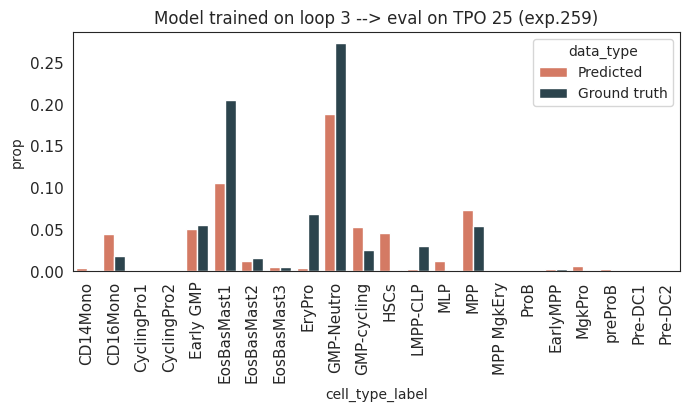

In [43]:
rename_map = {
    "CD14Mono": "CD14Mono",
    "CD16Mono": "CD16Mono",
    "CyclingPro1": "CyclingPro1",
    "CyclingPro2": "CyclingPro2",
    "Early_GMP": "Early GMP",
    "EosBasMast1": "EosBasMast1",
    "EosBasMast2": "EosBasMast2",
    "EosBasMast3": "EosBasMast3",
    "EryPro": "EryPro",
    "GMP-Neutro": "GMP-Neutro",
    "GMP_cycling": "GMP-cycling",
    "HSCs": "HSCs",
    "LMPP-CLP": "LMPP-CLP",
    "MLP": "MLP",
    "MPP": "MPP",
    "MPP_MgkEry": "MPP MgkEry",
    "MgkEryPro1": "MgkEryPro1",
    "MgkEryPro2": "MgkEryPro2",
    "ProB": "ProB",
    "earlyMPP": "EarlyMPP",
    "late_MgkPro": "MgkPro",
    "preProB": "preProB",
    "pre_cDC1": "Pre-DC1",
    "pre_cDC2": "Pre-DC2",
}

l3_model_l4_res_df["cell_type_label"] = l3_model_l4_res_df["cell_type"].map(rename_map)

sns.set_style("white")
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=l3_model_l4_res_df,
    x="cell_type_label",
    y="prop",
    hue="data_type",
    palette={"Ground truth": "#264653", "Predicted": "#e76f51"}
)

plt.xticks(rotation=90)
plt.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.title("Model trained on loop 3 --> eval on TPO 25 (exp.259)")
plt.savefig("../plots/l3_25.svg")
plt.show()

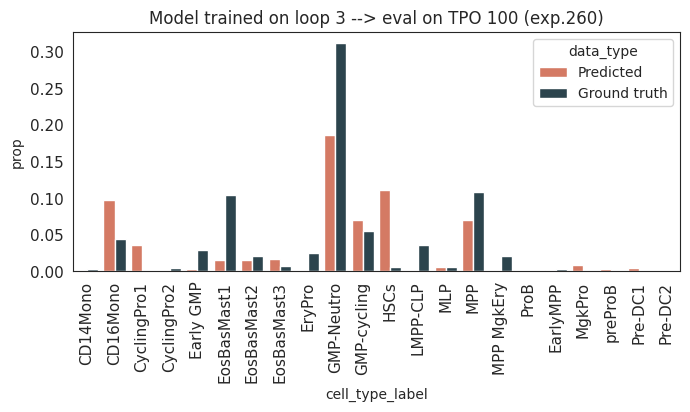

In [44]:
l3_model_l4p5_res_df["cell_type_label"] = l3_model_l4p5_res_df["cell_type"].map(rename_map)

sns.set_style("white")
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=l3_model_l4p5_res_df,
    x="cell_type_label",
    y="prop",
    hue="data_type",
    palette={"Ground truth": "#264653", "Predicted": "#e76f51"}
)

plt.xticks(rotation=90)
plt.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.title("Model trained on loop 3 --> eval on TPO 100 (exp.260)")
plt.savefig("../plots/l3_100.svg")
plt.show()

# Load loop4 fwd model 

In [23]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                     overrides=[
                        "paths=loop4_replicate",
                        "annotation=bloodplus_loop3"
                    ])

ANNOTATION_CFG_FILE = "../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [24]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [25]:
train_adata_g = target_prediction_model.train_data.adata

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [26]:
condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
recipes_to_predict_t = recipes_to_predict_t.to(forward_model.device).float()

batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: recipes_to_predict_t}}
forward_out = forward_model.predict(
    batch_dict,
    no_grad=True,
    fix_noise=False,
    num_time_steps=100
)
# Collect predictions 
y_pred = forward_out["target_prediction_data"]["cell_type"].view(recipes_to_predict_t.shape[0], 
                                                                 recipes_to_predict_t.shape[1], 
                                                                 len(classes))  
y_pred_softmax = F.softmax(y_pred, dim=-1)

In [27]:
y_pred_pred = y_pred_softmax.argmax(-1).cpu().numpy()
pred_classes_loop4 = classes[y_pred_pred]

In [28]:
pred_l4_tpo25 = pd.DataFrame(pred_classes_loop4[:,0])
pred_l4_tpo100 = pd.DataFrame(pred_classes_loop4[:,1])

pred_l4_tpo25 = pred_l4_tpo25.value_counts() / pred_l4_tpo25.shape[0]
pred_l4_tpo100 = pred_l4_tpo100.value_counts() / pred_l4_tpo100.shape[0]

In [29]:
l4_model_l4_res = {"data_type": [], 
                  "cell_type": [], 
                  "prop": []}

l4_model_l4p5_res = {"data_type": [], 
                     "cell_type": [], 
                     "prop": []}

In [30]:
for cl in classes:
    l4_model_l4_res["data_type"].append("Predicted")
    l4_model_l4_res["cell_type"].append(cl)
    try:
        l4_model_l4_res["prop"].append(pred_l4_tpo25[cl])
    except:
        l4_model_l4_res["prop"].append(0)

    l4_model_l4_res["data_type"].append("Ground truth")
    l4_model_l4_res["cell_type"].append(cl)
    try:
        l4_model_l4_res["prop"].append(gt_l4[cl])
    except:
        l4_model_l4_res["prop"].append(0)

    l4_model_l4p5_res["data_type"].append("Predicted")
    l4_model_l4p5_res["cell_type"].append(cl)
    try:
        l4_model_l4p5_res["prop"].append(pred_l4_tpo100[cl])
    except:
        l4_model_l4p5_res["prop"].append(0)

    l4_model_l4p5_res["data_type"].append("Ground truth")
    l4_model_l4p5_res["cell_type"].append(cl)
    try:
        l4_model_l4p5_res["prop"].append(gt_l4p5[cl])
    except:
        l4_model_l4p5_res["prop"].append(0)

In [31]:
l4_model_l4_res_df = pd.DataFrame(l4_model_l4_res)
l4_model_l4p5_res_df = pd.DataFrame(l4_model_l4p5_res)

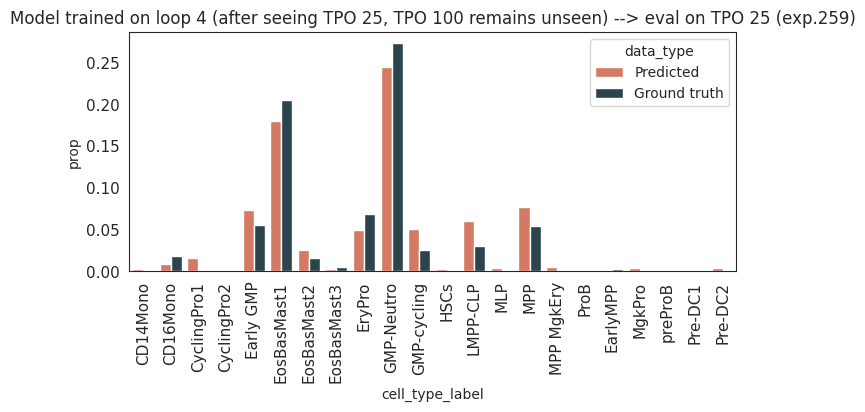

In [45]:
l4_model_l4_res_df["cell_type_label"] = l4_model_l4_res_df["cell_type"].map(rename_map)

sns.set_style("white")
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=l4_model_l4_res_df,
    x="cell_type_label",
    y="prop",
    hue="data_type",
    palette={"Ground truth": "#264653", "Predicted": "#e76f51"}
)

plt.xticks(rotation=90)
plt.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.title("Model trained on loop 4 (after seeing TPO 25, TPO 100 remains unseen) --> eval on TPO 25 (exp.259)")
plt.savefig("../plots/l4_25.svg")
plt.show()

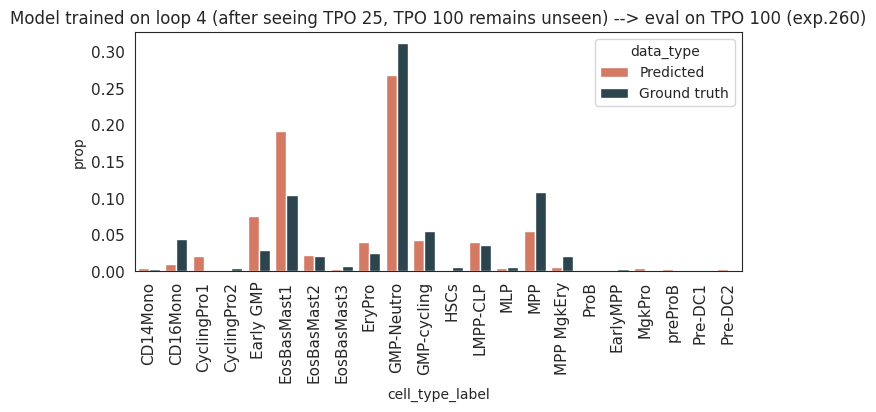

In [46]:
l4_model_l4p5_res_df["cell_type_label"] = l4_model_l4p5_res_df["cell_type"].map(rename_map)

sns.set_style("white")
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=l4_model_l4p5_res_df,
    x="cell_type_label",
    y="prop",
    hue="data_type",
    palette={"Ground truth": "#264653", "Predicted": "#e76f51"}
)

plt.xticks(rotation=90)
plt.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.title("Model trained on loop 4 (after seeing TPO 25, TPO 100 remains unseen) --> eval on TPO 100 (exp.260)")
plt.savefig("../plots/l4_100.svg")
plt.show()